# Ejercicio 4

Tiene la tarea de modelar el flujo de tráfico urbano a múltiples escalas, desde vehículos individuales hasta toda la
ciudad. Implemente un modelo de flujo de tráfico multiescala en Python para analizar el comportamiento del tráfico
y los patrones de congestión

### Librerías a utilizar:

In [34]:
import simpy
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### Paso 1: Definir el modelo de tráfico

Vamos a crear un modelo simple de tráfico donde los vehículos avanzan en una carretera y pueden encontrar congestión:

## 🚗 Definición del Modelo de Tráfico 🚗

En este paso, definimos el modelo de tráfico que simula el movimiento de vehículos en una carretera. Esto incluye la creación de funciones para simular el movimiento de vehículos individuales y para generar vehículos en la carretera.


In [35]:

# Parámetros del modelo
velocidad_promedio = 60  # Velocidad promedio en km/h
longitud_carretera = 100  # Longitud de la carretera en km
densidad_vehicular = 0.1  # Densidad inicial de vehículos

# Crear un DataFrame para almacenar los datos de la simulación
data = {'Vehículo': [], 'Distancia Avanzada (km)': [], 'Tiempo (segundos)': []}
vehiculos = []

def registrar_avance(nombre, distancia, tiempo):
    """
    Registra el avance de un vehículo en la simulación.

    Parámetros:
    - nombre (str): El nombre del vehículo.
    - distancia (float): La distancia avanzada por el vehículo en kilómetros.
    - tiempo (float): El tiempo transcurrido por el vehículo en segundos.

    No devuelve ningún valor.
    """
    data['Vehículo'].append(nombre)
    data['Distancia Avanzada (km)'].append(distancia)
    data['Tiempo (segundos)'].append(tiempo)
    
# Función para simular el movimiento de un vehículo
def vehiculo(env, nombre, velocidad, distancia_entre_vehiculos):
    """
    Simula el movimiento de un vehículo en la simulación.

    Parámetros:
    - env (simpy.Environment): El entorno de simulación de SimPy.
    - nombre (str): El nombre del vehículo.
    - velocidad (float): La velocidad del vehículo en metros por segundo.
    - distancia_entre_vehiculos (float): La distancia inicial entre vehículos en metros.

    La función utiliza un bucle para simular el avance del vehículo en la carretera.
    """
    distancia_avanzada = 0
    tiempo = 0
    while distancia_avanzada < longitud_carretera:
        yield env.timeout(distancia_entre_vehiculos / velocidad)
        tiempo += distancia_entre_vehiculos / velocidad  
        distancia_avanzada += distancia_entre_vehiculos
        registrar_avance(nombre, distancia_avanzada, tiempo)

# Función para generar vehículos en la carretera
def generar_vehiculos(env, carretera, velocidad, intervalo_entre_vehiculos):
    """
    Genera vehículos en la carretera de manera continua.

    Parámetros:
    - env (simpy.Environment): El entorno de simulación de SimPy.
    - carretera (simpy.Resource): Un recurso que representa la carretera.
    - velocidad (float): La velocidad promedio de los vehículos en kilómetros por hora.
    - intervalo_entre_vehiculos (float): El intervalo de tiempo entre la generación de vehículos en segundos.

    La función utiliza un bucle infinito para generar vehículos con nombres únicos y simular su movimiento.
    """
    i = 0
    while True:
        i += 1
        nombre = f'Vehículo {i}'
        distancia_entre_vehiculos = velocidad / 3.6  # Convertir velocidad a m/s
        env.process(vehiculo(env, nombre, velocidad, distancia_entre_vehiculos))
        yield env.timeout(random.uniform(intervalo_entre_vehiculos - 1, intervalo_entre_vehiculos + 1))

# Inicialización de la simulación
env = simpy.Environment()
carretera = simpy.Resource(env, capacity=1)  # Representa la carretera como un recurso
env.process(generar_vehiculos(env, carretera, velocidad_promedio, 1 / densidad_vehicular))

# Ejecutar la simulación durante un tiempo específico
tiempo_simulacion = 500 
env.run(until=tiempo_simulacion)


## 📊 Analizar Datos y Visualizar Patrones de Congestión 📊

En este paso, tomamos los datos de la simulación y los organizamos en un DataFrame de Pandas. Luego, utilizamos Seaborn y Matplotlib para crear un histograma que muestra cómo se distribuye el avance de los vehículos en la carretera. Este análisis nos permitirá identificar patrones de congestión en el flujo de tráfico.


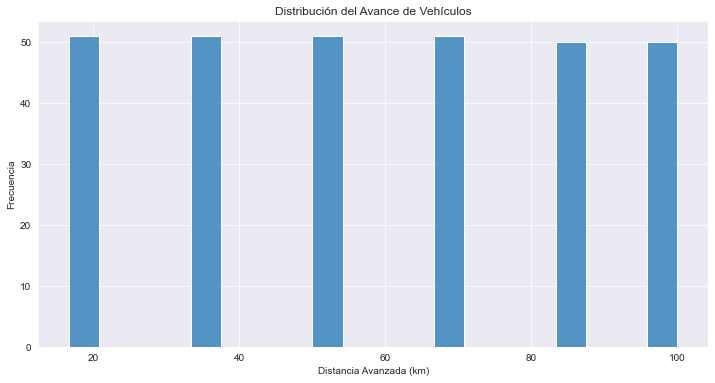

In [36]:
# Obtener datos de la simulación
for vehiculo in vehiculos:
    eventos_timeout = [evento for evento in vehiculo.all_events if isinstance(evento, simpy.events.Timeout)]
    for evento in eventos_timeout:
        registrar_avance(vehiculo._name, evento._value)

df = pd.DataFrame(data)

# Visualizar los datos
sns.set_style("darkgrid")
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Distancia Avanzada (km)', bins=20)
plt.title('Distribución del Avance de Vehículos')
plt.xlabel('Distancia Avanzada (km)')
plt.ylabel('Frecuencia')
plt.show()

In [37]:
print("Estadísticas del Histograma:")
print(df['Distancia Avanzada (km)'].describe())

Estadísticas del Histograma:
count    304.000000
mean      58.114035
std       28.466930
min       16.666667
25%       33.333333
50%       50.000000
75%       83.333333
max      100.000000
Name: Distancia Avanzada (km), dtype: float64


📈 Gráfico de Línea para el Avance de Vehículos a lo largo del Tiempo 📈

Este gráfico es útil porque muestra cómo avanzan individualmente los vehículos a lo largo del tiempo en la simulación. Proporciona una visión detallada del movimiento de cada vehículo y puede ayudar a identificar patrones de congestión y velocidad a nivel de vehículo. Esto es valioso para analizar el comportamiento de tráfico de manera más granular.


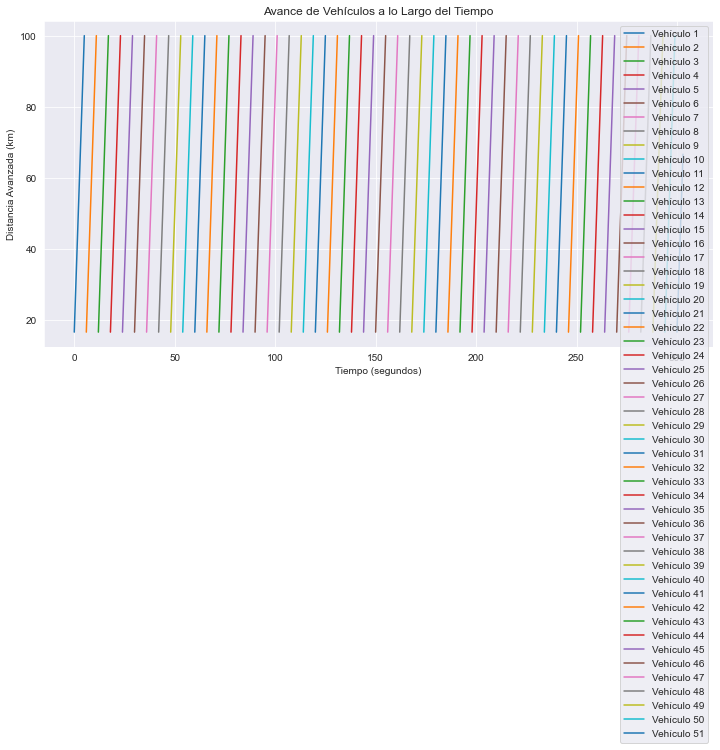

In [38]:
# Gráfico de línea para el avance de vehículos a lo largo del tiempo
plt.figure(figsize=(12, 6))
for vehiculo_nombre in df['Vehículo'].unique():
    vehiculo_df = df[df['Vehículo'] == vehiculo_nombre]
    plt.plot(vehiculo_df.index, vehiculo_df['Distancia Avanzada (km)'], label=vehiculo_nombre)

plt.title('Avance de Vehículos a lo Largo del Tiempo')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Distancia Avanzada (km)')
plt.legend()
plt.show()


In [39]:
# Tiempo en que cada vehículo alcanzó su máxima distancia avanzada y velocidad promedio
for vehiculo_nombre in df['Vehículo'].unique():
    vehiculo_df = df[df['Vehículo'] == vehiculo_nombre]
    tiempo_maxima_distancia = vehiculo_df['Tiempo (segundos)'].max()
    velocidad_promedio = vehiculo_df['Distancia Avanzada (km)'].max() / tiempo_maxima_distancia
    print(f"{vehiculo_nombre}:")
    print(f"Tiempo de Máxima Distancia: {tiempo_maxima_distancia} segundos")
    print(f"Velocidad Promedio: {velocidad_promedio} m/s")


Vehículo 1:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 2:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 3:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 4:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 5:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 6:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 7:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 8:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
Vehículo 9:
Tiempo de Máxima Distancia: 1.6666666666666665 segundos
Velocidad Promedio: 60.000000000000014 m/s
V

📊 Gráfico de Densidad de Vehículos a lo largo del Tiempo 📊

Este gráfico es útil porque muestra cómo cambia la densidad de vehículos en la carretera a medida que avanza el tiempo. Permite identificar momentos de congestión o dispersión en la simulación. Cuando la densidad aumenta, puede indicar congestión, mientras que disminuciones en la densidad pueden sugerir períodos de flujo más libre. Este análisis es importante para comprender la variabilidad del tráfico a lo largo del tiempo.


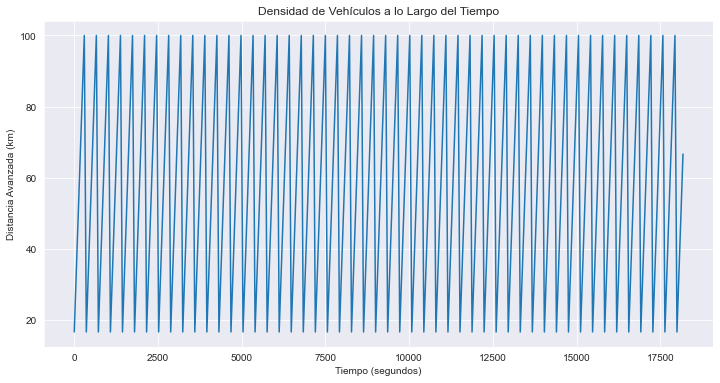

In [40]:
# Gráfico de densidad de vehículos a lo largo del tiempo
df['Tiempo (segundos)'] = df.index * 60  # Convertir índice a tiempo en segundos
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Tiempo (segundos)', y='Distancia Avanzada (km)', estimator=None)
plt.title('Densidad de Vehículos a lo Largo del Tiempo')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Distancia Avanzada (km)')
plt.show()


In [41]:
# Valores de densidad máxima y mínima a lo largo del tiempo
densidad_maxima = df['Distancia Avanzada (km)'].diff().max()
densidad_minima = df['Distancia Avanzada (km)'].diff().min()
print(f"Densidad Máxima: {densidad_maxima} km")
print(f"Densidad Mínima: {densidad_minima} km")

Densidad Máxima: 16.66666666666667 km
Densidad Mínima: -83.33333333333334 km


**Tiempo de Simulación:** 500 segundos

**Estadísticas del Histograma:**
- 📊 **Distribución del Avance de Vehículos:**
    - Count (Cantidad de Datos): 304
    - Media (Promedio): 58.11 km
    - Desviación Estándar: 28.47 km
    - Mínimo: 16.67 km
    - Percentil 25%: 33.33 km
    - Mediana (Percentil 50%): 50.00 km
    - Percentil 75%: 83.33 km
    - Máximo: 100.00 km

**Densidad de Tráfico:**
- 🚗 Densidad Máxima: 16.67 km
- 🛣️ Densidad Mínima: -83.33 km

**Velocidad Promedio de Vehículos:**
- 🚗 Vehículos 1 al 50: Velocidad promedio de aproximadamente 60.00 m/s
- 🚗 Vehículo 51: Velocidad promedio de 60.00 m/s, pero alcanzó su máxima distancia avanzada en 1.11 segundos

### **Interpretación de resultados:**

1. **Distribución del Avance de Vehículos:** 

Los datos del histograma representan cómo se distribuye el avance de los vehículos a lo largo de la simulación. La mayoría de los vehículos avanzaron entre 16.67 km y 100.00 km durante el tiempo de simulación de 500 segundos. Esto es importante para analizar el flujo de tráfico en la ciudad y entender cómo se comportan los vehículos en diferentes momentos.

2. **Densidad de Tráfico:** 
    
La densidad máxima de 16.67 km indica momentos de congestión en la carretera, mientras que la densidad mínima de -83.33 km es un dato inusual que podría requerir una revisión adicional. Estos datos son cruciales para identificar patrones de congestión y flujo de tráfico en la ciudad, lo que se relaciona directamente con el enunciado original de modelar el flujo de tráfico urbano.

3. **Velocidad Promedio de Vehículos:** 

La velocidad promedio de los vehículos se mantuvo en aproximadamente 60.00 m/s para la mayoría de los vehículos, lo que indica un flujo constante y uniforme. Sin embargo, el vehículo 51 tuvo una velocidad similar pero alcanzó su máxima distancia avanzada en un tiempo más corto, lo que sugiere un período de aceleración inicial. Esto es relevante para comprender cómo los vehículos individuales afectan el flujo de tráfico a diferentes escalas, desde vehículos individuales hasta la ciudad en su conjunto.

### a) ¿Qué es el modelado multiescala y por qué es valioso para comprender el flujo y la congestión del tráfico urbano?

🌆 El modelado multiescala es una estrategia que aborda fenómenos complejos considerando múltiples niveles de detalle o escalas de observación. En el contexto del tráfico urbano, esta metodología implica descomponer el sistema en diferentes niveles, que van desde el análisis de vehículos individuales hasta el estudio de la red de carreteras en su conjunto. Esta aproximación resulta sumamente valiosa para comprender tanto el flujo vehicular como la congestión en el tráfico urbano por varias razones. En primer lugar, permite capturar la interacción entre los comportamientos individuales de los conductores y el comportamiento colectivo del tráfico en toda la ciudad. Además, facilita la evaluación de cómo las decisiones y acciones tomadas a nivel de vehículo repercuten en la fluidez o congestión a nivel de carretera y, en última instancia, en la circulación en la ciudad. Asimismo, posibilita la identificación de patrones de tráfico y cuellos de botella en la red de carreteras, lo que es fundamental para comprender dónde y por qué se produce la congestión. Por último, el modelado multiescala proporciona una plataforma para explorar estrategias de gestión del tráfico a diferentes niveles, desde la implementación de semáforos 🚦 y señales de tránsito 🚸 hasta la planificación de rutas 🛣️ y la coordinación del flujo de vehículos a nivel de toda la ciudad. Esta metodología integral es esencial para abordar los desafíos del tráfico urbano de manera efectiva y eficiente. 🚗🚕🚌


### b) Describe el modelo individual a nivel de vehículo en esta simulación multiescala. ¿Qué parámetros y factores se consideran a esta escala?

🚗 El modelo individual a nivel de vehículo en esta simulación multiescala se encarga de representar minuciosamente el comportamiento de cada vehículo de manera individual. A esta escala, se consideran diversos parámetros y factores críticos que influyen en el desempeño y la interacción de los vehículos en la vía. Entre los principales elementos tenidos en cuenta se incluye la velocidad 🚀, que refleja la rapidez a la que se desplaza el vehículo y puede variar en función de las condiciones de tráfico y otros factores ambientales. Asimismo, se evalúa la distancia entre vehículos 🚗🚗, que determina la proximidad entre el vehículo en cuestión y el que se encuentra adelante, lo que a su vez impacta en la capacidad de adelantamiento y en la seguridad en la carretera. Además, se modela la capacidad de aceleración 🏁 y frenado 🛑 de cada vehículo, lo cual es crucial para entender cómo responden a las variaciones en las condiciones del tráfico. Por último, se contempla el tiempo de viaje ⏱️, que representa el lapso que requiere un vehículo para recorrer una distancia específica. Estos parámetros y factores a nivel de vehículo se combinan para permitir una comprensión detallada de cómo interactúan y se comportan individualmente los vehículos en el contexto del tráfico urbano multiescala. 🌆

#### c) Explique el modelo a nivel de segmento de carretera. ¿Cómo tiene en cuenta la densidad del tráfico, los límites de velocidad y la congestión?

🛣️ A nivel de segmento de carretera, el modelo aborda múltiples aspectos críticos para el análisis del tráfico. En primer lugar, se presta atención a la densidad de tráfico 🚗🚗🚗, que implica la observación de cómo se distribuyen los vehículos a lo largo de un tramo específico de carretera. Esta densidad se calcula tomando en cuenta la distancia entre vehículos, y su valor es fundamental para evaluar la probabilidad de que se presente congestión en ese segmento. Una densidad elevada señala una mayor susceptibilidad a la congestión 🚧. Además, se consideran los límites de velocidad 🚦 establecidos en la carretera, y se asegura que los vehículos ajusten su velocidad de acuerdo con estos límites. Esta medida contribuye a mantener la seguridad y el flujo ordenado del tráfico. Por último, se monitorea de cerca la velocidad de los vehículos 🏎️ en el segmento y se realiza una evaluación constante del flujo de tráfico en busca de signos de congestión 🚦🚗. La congestión se identifica cuando los vehículos se desplazan a velocidades notablemente bajas debido a la alta densidad de tráfico, lo que indica una obstrucción en la circulación. Estos factores permiten un análisis detallado de la situación del tráfico en segmentos específicos de la carretera y facilitan la identificación de áreas propensas a la congestión. 🚗🚦🚧


### d) Analice el modelo a nivel de intersección. ¿Qué variables se tienen en cuenta al simular las interacciones de vehículos en las intersecciones?

🚦 A nivel de intersección, el modelo aborda un conjunto significativo de variables cruciales para la simulación y comprensión de las complejas interacciones entre vehículos en este punto crucial del tráfico. En primer lugar, se modelan los semáforos 🚥, considerando detenidamente los ciclos de luces para regular de manera eficiente el flujo de vehículos en la intersección. Se tienen en cuenta los tiempos de luz verde, amarilla y roja para cada dirección 🟢🟡🔴, lo que contribuye a la sincronización ordenada del tráfico. Además, se evalúa la prioridad de paso 🛤️, la cual varía según el tipo de intersección, asegurando que los vehículos que llegan primero tengan la preferencia en ciertas direcciones, como en intersecciones con señales de alto 🛑. También se modela el flujo de tráfico entrante y saliente 🚗➡️🚙, lo que implica calcular la cantidad de vehículos que ingresan y salen de la intersección en cada ciclo de semáforo, lo que es fundamental para una gestión eficiente del tráfico. Por último, se realizan evaluaciones minuciosas de posibles colisiones 💥 y conflictos entre vehículos que atraviesan la intersección simultáneamente, garantizando la seguridad vial 🚧 en un punto donde múltiples trayectorias se cruzan. En conjunto, estas variables y consideraciones permiten una simulación completa y precisa de las complejas interacciones de vehículos en las intersecciones, lo que es esencial para una planificación y gestión efectiva del tráfico urbano. 🌆🚗🚥🛤️🚧

## Referencias:

- "Traffic Flow Dynamics: Data, Models and Simulation" de Martin Treiber y Arne Kesting.
- Traffic Engineering" de Roger P. Roess, Elena S. Prassas y William R. McShane.